In [6]:
# ============================================================
# MODULE 1: INSTALLATION, IMPORTS AND CONFIGURATION
# SPORTS IMAGE CLASSIFICATION
# ============================================================

# Install required libraries
!pip -q install kagglehub seaborn scikit-learn pandas pillow opencv-python

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------

import os
import re
import time
import hashlib
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -------------------------------
# RANDOM SEED
# -------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------------
# CONFIGURATION
# -------------------------------

IMG_SIZE = (224, 224)

BATCH_SIZE = 8

# Use 1 epoch for testing.
# Change to 3-10 for final training.
EPOCHS = 1

AUTOTUNE = tf.data.AUTOTUNE

# Dataset and output directories
DATASET_DIR = Path("/content/sports_dataset")

OUTPUT_DIR = Path("/content/sports_outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# -------------------------------
# GPU CHECK
# -------------------------------

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:", gpus)
else:
    print("WARNING: GPU not available. Enable T4 GPU in Colab.")

# -------------------------------
# BASIC INFORMATION
# -------------------------------

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Output directory:", OUTPUT_DIR)

print("\nMODULE 1 COMPLETED")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Image size: (224, 224)
Batch size: 8
Epochs: 1
Output directory: /content/sports_outputs

MODULE 1 COMPLETED


100%|██████████| 424M/424M [00:03<00:00, 122MB/s]

Extracting files...


Dataset directory: /root/.cache/kagglehub/datasets/gpiosenka/sports-classification/versions/9
Total raw images: 14492
Total classes: 100

Initial class distribution:
label
football              201
formula 1 racing      200
nascar racing         199
baseball              184
hockey                182
                     ... 
horseshoe pitching    112
arm wrestling         109
wingsuit flying       108
ultimate              107
sky surfing            69
Name: count, Length: 100, dtype: int64

Checking invalid images...
Invalid images: 0
Images after invalid-image removal: 14492

Calculating image hashes...
Exact duplicate images: 0
Images after duplicate removal: 14492

Class names:
0 : air hockey
1 : ampute football
2 : archery
3 : arm wrestling
4 : axe throwing
5 : balance beam
6 : barell racing
7 : baseball
8 : basketball
9 : baton twirling
10 : bike polo
11 : billiards
12 : bmx
13 : bobsled
14 : bowling
15 : boxing
16 : bull riding
17 : bungee jumping
18 : canoe slamon
19 : cheerle

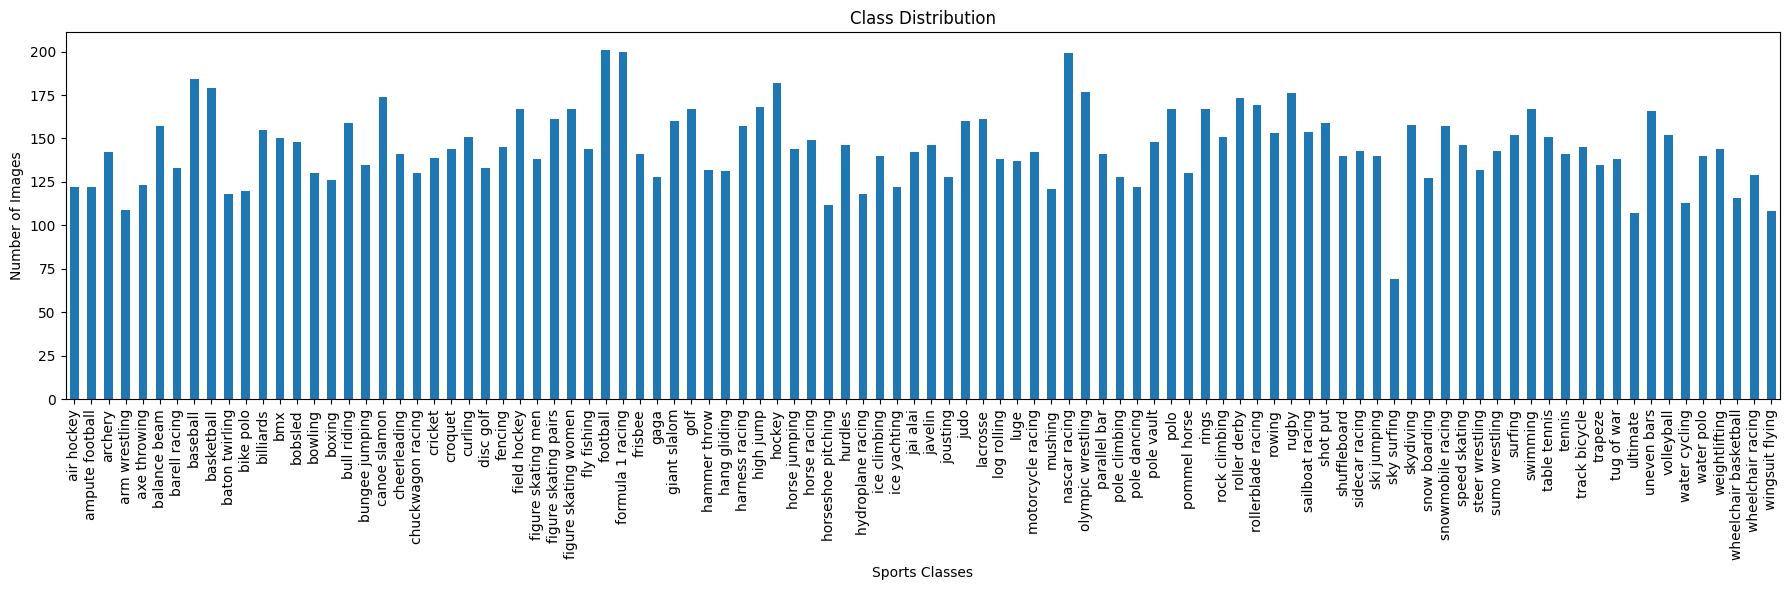


Cleaned dataset index saved at: /content/sports_outputs/cleaned_dataset_index.csv

DATASET SPLIT INFORMATION
Training images: 10144
Validation images: 2174
Testing images: 2174
Total images: 14492
Training percentage: 70.0 %
Validation percentage: 15.0 %
Testing percentage: 15.0 %

DATA LEAKAGE CHECK
Train and validation overlap: 0
Train and test overlap: 0
Validation and test overlap: 0

MODULE 2 COMPLETED


In [7]:
# ============================================================
# MODULE 2: DATASET DOWNLOAD, CLEANING AND DATA SPLITTING
# ============================================================

import kagglehub

# -------------------------------
# DOWNLOAD DATASET
# -------------------------------

print("Downloading dataset...")

downloaded_path = kagglehub.dataset_download(
    "gpiosenka/sports-classification"
)

DATASET_DIR = Path(downloaded_path)

print("Dataset directory:", DATASET_DIR)

# -------------------------------
# FIND ALL IMAGE FILES
# -------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

records = []

for image_path in DATASET_DIR.rglob("*"):

    if (
        image_path.is_file()
        and image_path.suffix.lower() in IMAGE_EXTENSIONS
    ):

        # Parent folder is treated as the class label
        label = image_path.parent.name

        records.append(
            (
                str(image_path),
                label
            )
        )

# Create DataFrame
df = pd.DataFrame(
    records,
    columns=[
        "path",
        "label"
    ]
)

# Remove duplicate file paths
df = df.drop_duplicates(
    subset=["path"]
).reset_index(drop=True)

print("Total raw images:", len(df))

print(
    "Total classes:",
    df["label"].nunique()
)

print("\nInitial class distribution:")
print(df["label"].value_counts())

# -------------------------------
# CHECK IMAGE VALIDITY
# -------------------------------

def valid_image(image_path):

    try:

        with Image.open(image_path) as image:

            image.verify()

        return True

    except Exception:

        return False


print("\nChecking invalid images...")

df["valid"] = df["path"].apply(valid_image)

invalid_count = (~df["valid"]).sum()

print("Invalid images:", invalid_count)

# Keep only valid images
df = df[df["valid"]].drop(
    columns=["valid"]
).reset_index(drop=True)

print(
    "Images after invalid-image removal:",
    len(df)
)

# -------------------------------
# REMOVE EXACT DUPLICATES
# USING SHA-256 HASH
# -------------------------------

def calculate_sha256(file_path):

    hash_object = hashlib.sha256()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            data = file.read(1024 * 1024)

            if not data:
                break

            hash_object.update(data)

    return hash_object.hexdigest()


print("\nCalculating image hashes...")

df["sha256"] = df["path"].apply(
    calculate_sha256
)

duplicate_count = df.duplicated(
    subset=["sha256"]
).sum()

print(
    "Exact duplicate images:",
    duplicate_count
)

# Remove duplicate images
df = df.drop_duplicates(
    subset=["sha256"]
).drop(
    columns=["sha256"]
).reset_index(drop=True)

print(
    "Images after duplicate removal:",
    len(df)
)

# -------------------------------
# CLASS LABEL ENCODING
# -------------------------------

class_names = sorted(
    df["label"].unique()
)

class_to_id = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

df["class_id"] = df["label"].map(
    class_to_id
)

NUM_CLASSES = len(class_names)

print("\nClass names:")

for index, class_name in enumerate(class_names):

    print(index, ":", class_name)

print(
    "\nTotal number of classes:",
    NUM_CLASSES
)

# -------------------------------
# CLASS DISTRIBUTION
# -------------------------------

class_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(18, 6))

class_distribution.plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.xlabel("Sports Classes")

plt.ylabel("Number of Images")

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

# -------------------------------
# SAVE CLEANED DATASET INDEX
# -------------------------------

cleaned_index_path = (
    OUTPUT_DIR / "cleaned_dataset_index.csv"
)

df.to_csv(
    cleaned_index_path,
    index=False
)

print(
    "\nCleaned dataset index saved at:",
    cleaned_index_path
)

# -------------------------------
# STRATIFIED 70/15/15 SPLIT
# -------------------------------

# First split:
# 70% training and 30% temporary data

train_df, temporary_df = train_test_split(

    df,

    test_size=0.30,

    stratify=df["class_id"],

    random_state=SEED
)

# Second split:
# Temporary data divided equally:
# 15% validation and 15% testing

validation_df, test_df = train_test_split(

    temporary_df,

    test_size=0.50,

    stratify=temporary_df["class_id"],

    random_state=SEED
)

# -------------------------------
# RESET DATAFRAME INDEXES
# -------------------------------

train_df = train_df.reset_index(
    drop=True
)

validation_df = validation_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

# -------------------------------
# DISPLAY SPLIT INFORMATION
# -------------------------------

print("\nDATASET SPLIT INFORMATION")

print(
    "Training images:",
    len(train_df)
)

print(
    "Validation images:",
    len(validation_df)
)

print(
    "Testing images:",
    len(test_df)
)

total_images = (
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

print(
    "Total images:",
    total_images
)

print(
    "Training percentage:",
    round(len(train_df) / total_images * 100, 2),
    "%"
)

print(
    "Validation percentage:",
    round(len(validation_df) / total_images * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(test_df) / total_images * 100, 2),
    "%"
)

# -------------------------------
# SAVE DATASET SPLITS
# -------------------------------

train_df.to_csv(
    OUTPUT_DIR / "train_split.csv",
    index=False
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_split.csv",
    index=False
)

test_df.to_csv(
    OUTPUT_DIR / "test_split.csv",
    index=False
)

# -------------------------------
# VERIFY DATA LEAKAGE
# -------------------------------

train_paths = set(train_df["path"])

validation_paths = set(
    validation_df["path"]
)

test_paths = set(
    test_df["path"]
)

print("\nDATA LEAKAGE CHECK")

print(
    "Train and validation overlap:",
    len(train_paths.intersection(validation_paths))
)

print(
    "Train and test overlap:",
    len(train_paths.intersection(test_paths))
)

print(
    "Validation and test overlap:",
    len(validation_paths.intersection(test_paths))
)

print("\nMODULE 2 COMPLETED")

Training batches: 1268
Validation batches: 272
Testing batches: 272


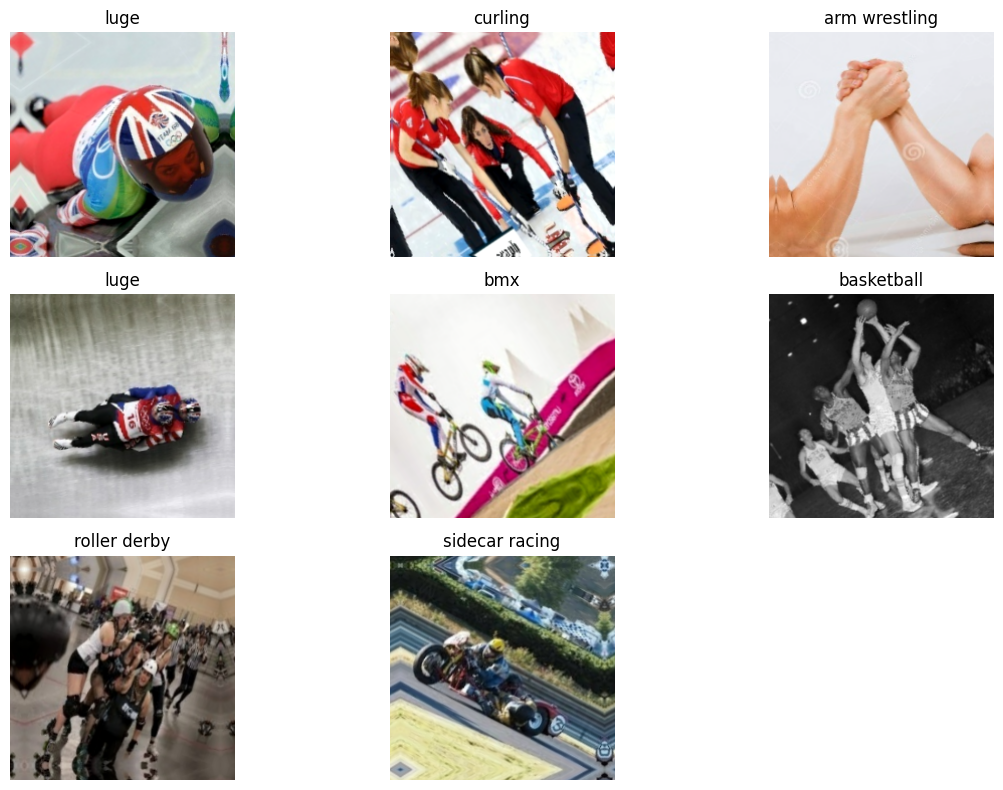

MODULE 3 COMPLETED


In [8]:
# ============================================================
# MODULE 3: IMAGE PREPROCESSING AND AUGMENTATION
# ============================================================

# Data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation"
)


def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def preprocess_train(image_path, label):

    image, label = load_image(
        image_path,
        label
    )

    image = data_augmentation(
        image,
        training=True
    )

    return image, label


def preprocess_validation(image_path, label):

    image, label = load_image(
        image_path,
        label
    )

    return image, label


def create_dataset(dataframe, training=False):

    image_paths = dataframe["path"].values

    labels = dataframe["class_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            image_paths,
            labels
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

        dataset = dataset.map(
            preprocess_train,
            num_parallel_calls=AUTOTUNE
        )

    else:

        dataset = dataset.map(
            preprocess_validation,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.map(
        lambda image, label: (
            image,
            tf.one_hot(
                label,
                depth=NUM_CLASSES
            )
        ),
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# Create datasets
train_dataset = create_dataset(
    train_df,
    training=True
)

validation_dataset = create_dataset(
    validation_df,
    training=False
)

test_dataset = create_dataset(
    test_df,
    training=False
)

print("Training batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Testing batches:", len(test_dataset))

# Display sample images
images, labels = next(iter(train_dataset))

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        tf.cast(images[i], tf.uint8)
    )

    class_id = tf.argmax(
        labels[i]
    ).numpy()

    plt.title(
        class_names[class_id]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("MODULE 3 COMPLETED")

In [9]:
# ============================================================
# MODULE 4: SEVEN DEEP LEARNING ARCHITECTURES
# ============================================================

from tensorflow.keras.applications import (
    ResNet50,
    EfficientNetB4,
    MobileNetV2,
    Xception,
    DenseNet121
)

from tensorflow.keras.applications import (
    resnet50,
    mobilenet_v2,
    xception,
    densenet
)

# ConvNeXt availability
from tensorflow.keras.applications import ConvNeXtTiny


# ------------------------------------------------------------
# CBAM ATTENTION BLOCK
# ------------------------------------------------------------

def cbam_block(feature_map, reduction_ratio=8):

    channels = feature_map.shape[-1]

    # Channel attention
    average_pool = layers.GlobalAveragePooling2D(
        keepdims=True
    )(feature_map)

    max_pool = layers.GlobalMaxPooling2D(
        keepdims=True
    )(feature_map)

    shared_dense_1 = layers.Dense(
        max(channels // reduction_ratio, 1),
        activation="relu"
    )

    shared_dense_2 = layers.Dense(
        channels,
        activation="sigmoid"
    )

    average_attention = shared_dense_2(
        shared_dense_1(average_pool)
    )

    max_attention = shared_dense_2(
        shared_dense_1(max_pool)
    )

    channel_attention = layers.Add()(
        [
            average_attention,
            max_attention
        ]
    )

    channel_attention = layers.Activation(
        "sigmoid"
    )(channel_attention)

    refined_feature = layers.Multiply()(
        [
            feature_map,
            channel_attention
        ]
    )

    # Spatial attention
    average_spatial = layers.Lambda(
        lambda x: tf.reduce_mean(x, axis=-1, keepdims=True)
    )(refined_feature)

    max_spatial = layers.Lambda(
        lambda x: tf.reduce_max(x, axis=-1, keepdims=True)
    )(refined_feature)

    spatial_features = layers.Concatenate(
        axis=-1
    )(
        [
            average_spatial,
            max_spatial
        ]
    )

    spatial_attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(spatial_features)

    output = layers.Multiply()(
        [
            refined_feature,
            spatial_attention
        ]
    )

    return output


# ------------------------------------------------------------
# PREPROCESSING FUNCTIONS
# ------------------------------------------------------------

def preprocess_input(model_name, images):

    if model_name == "ResNet50":

        return resnet50.preprocess_input(images)

    elif model_name == "MobileNetV2":

        return mobilenet_v2.preprocess_input(images)

    elif model_name == "Xception":

        return xception.preprocess_input(images)

    elif model_name == "DenseNet121":

        return densenet.preprocess_input(images)

    # EfficientNet and ConvNeXt include
    # preprocessing internally.
    else:

        return images


# ------------------------------------------------------------
# MODEL CREATION
# ------------------------------------------------------------

def build_model(model_name):

    inputs = keras.Input(
        shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ),
        name="input_image"
    )

    processed_inputs = layers.Lambda(
        lambda x: preprocess_input(
            model_name,
            x
        )
    )(inputs)

    if model_name == "ResNet50":

        backbone = ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    elif model_name == "ResNet50_CBAM":

        backbone = ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = True

    elif model_name == "EfficientNetB4":

        backbone = EfficientNetB4(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    elif model_name == "ConvNeXtTiny":

        backbone = ConvNeXtTiny(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    elif model_name == "MobileNetV2":

        backbone = MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    elif model_name == "Xception":

        backbone = Xception(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    elif model_name == "DenseNet121":

        backbone = DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        )

        use_cbam = False

    else:

        raise ValueError(
            "Unknown model: " + model_name
        )

    backbone.trainable = False

    features = backbone(
        processed_inputs,
        training=False
    )

    if use_cbam:

        features = cbam_block(
            features
        )

    features = layers.GlobalAveragePooling2D()(
        features
    )

    features = layers.BatchNormalization()(
        features
    )

    features = layers.Dropout(
        0.4
    )(features)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(features)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=model_name
    )

    return model


# ------------------------------------------------------------
# CREATE ALL SEVEN MODELS
# ------------------------------------------------------------

MODEL_NAMES = [
    "ResNet50",
    "ResNet50_CBAM",
    "EfficientNetB4",
    "ConvNeXtTiny",
    "MobileNetV2",
    "Xception",
    "DenseNet121"
]

models = {}

for model_name in MODEL_NAMES:

    print("\nCreating:", model_name)

    models[model_name] = build_model(
        model_name
    )

    print(
        "Parameters:",
        models[model_name].count_params()
    )

print("\nAll seven models created.")

print("MODULE 4 COMPLETED")



Creating: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parameters: 23800804

Creating: ResNet50_CBAM
Parameters: 24851783

Creating: EfficientNetB4
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parameters: 17860291

Creating: ConvNeXtTiny
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parameters: 27900100

Creating: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameters: 2391204

Creating: Xception
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parameters: 21074572

Creating: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameters: 7144100

All seven models created.
MODULE 4 COMPLETED



Training model: ResNet50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 162s 118ms/step - accuracy: 0.3968 - loss: 3.0281 - val_accuracy: 0.7806 - val_loss: 1.7142 - learning_rate: 3.0000e-04

Evaluation results:
Accuracy: 0.7897884084636615
Precision: 0.807813151462547
Recall: 0.7897884084636615
F1 Score: 0.7881600705865055
ROC-AUC: 0.9956687934946787

Training model: ResNet50_CBAM
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 169s 122ms/step - accuracy: 0.1545 - loss: 4.0244 - val_accuracy: 0.5892 - val_loss: 2.4268 - learning_rate: 3.0000e-04

Evaluation results:
Accuracy: 0.5726770929162833
Precision: 0.6243060029755482
Recall: 0.5726770929162833
F1 Score: 0.5616810757725227
ROC-AUC: 0.9781876147365101

Training model: EfficientNetB4
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 226s 136ms/step - accuracy: 0.4713 - loss: 2.7655 - val_accuracy: 0.8367 - val_loss: 1.4813 - learning_rate: 3.0000e-04

Evaluation results:
Accuracy: 0.8376264949402024
Precision: 0.8491923609843989
Recall: 0.8376264949402024
F1 Score: 0.834469883091

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Parameters,Training Time (seconds)
2,EfficientNetB4,0.837626,0.849192,0.837626,0.834470,0.997770,17860291,226.086365
0,ResNet50,0.789788,0.807813,0.789788,0.788160,0.995669,23800804,162.652592
3,ConvNeXtTiny,0.783349,0.799846,0.783349,0.780068,0.996716,27900100,179.360102
5,Xception,0.743790,0.762692,0.743790,0.738507,0.994585,21074572,196.096905
6,DenseNet121,0.728151,0.749947,0.728151,0.718659,0.992960,7144100,214.097698
4,MobileNetV2,0.706072,0.734432,0.706072,0.698773,0.992338,2391204,149.996539
1,ResNet50_CBAM,0.572677,0.624306,0.572677,0.561681,0.978188,24851783,169.239403


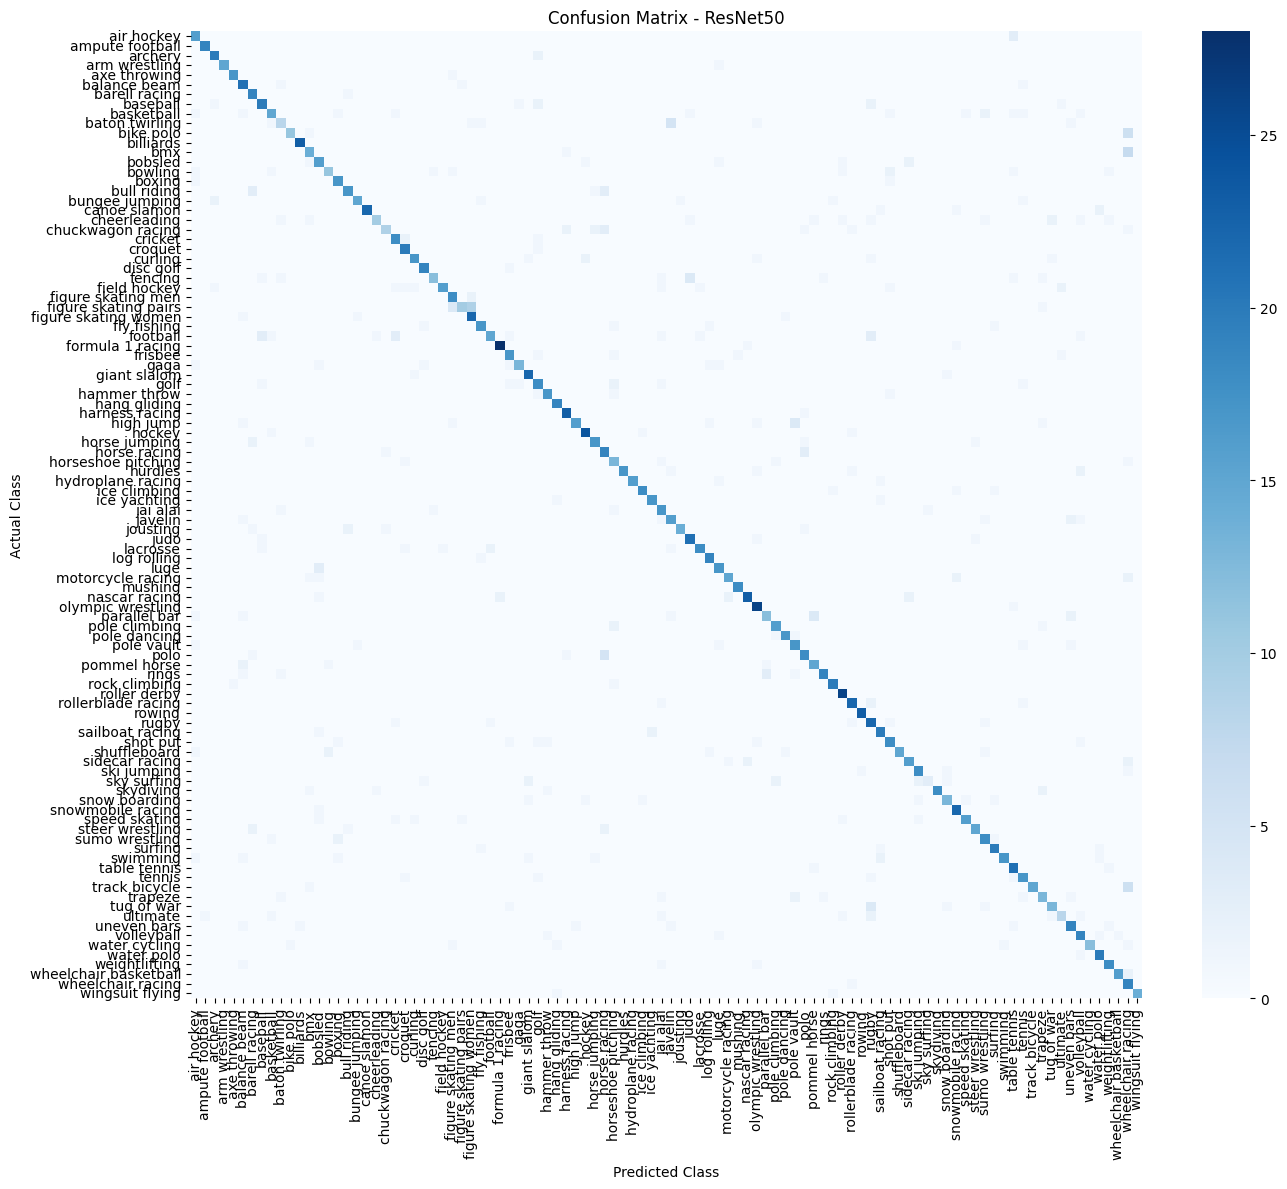

                       precision    recall  f1-score   support

           air hockey       0.67      0.84      0.74        19
      ampute football       0.95      1.00      0.97        19
              archery       0.83      0.91      0.87        22
        arm wrestling       1.00      0.94      0.97        16
         axe throwing       0.94      0.94      0.94        18
         balance beam       0.66      0.88      0.75        24
        barell racing       0.68      0.95      0.79        20
             baseball       0.74      0.74      0.74        27
           basketball       0.71      0.56      0.62        27
       baton twirling       0.57      0.44      0.50        18
            bike polo       0.92      0.61      0.73        18
            billiards       0.96      1.00      0.98        23
                  bmx       0.67      0.64      0.65        22
              bobsled       0.64      0.73      0.68        22
              bowling       0.79      0.55      0.65  

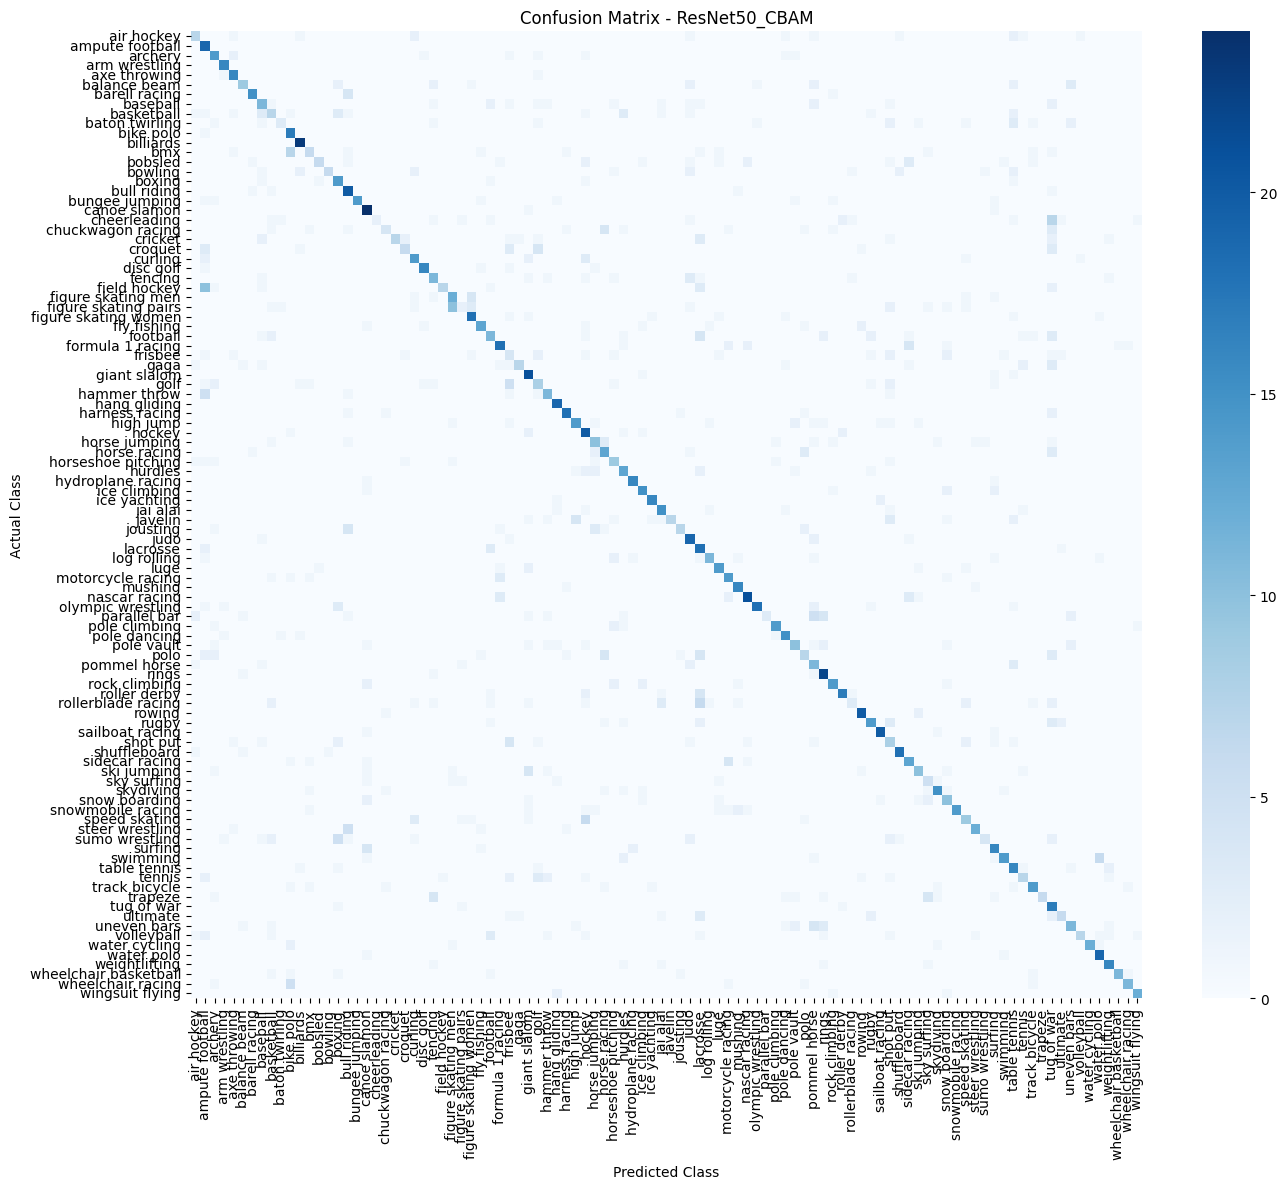

                       precision    recall  f1-score   support

           air hockey       0.47      0.37      0.41        19
      ampute football       0.34      1.00      0.51        19
              archery       0.50      0.64      0.56        22
        arm wrestling       0.80      1.00      0.89        16
         axe throwing       0.67      0.89      0.76        18
         balance beam       0.64      0.38      0.47        24
        barell racing       0.83      0.75      0.79        20
             baseball       0.41      0.41      0.41        27
           basketball       0.30      0.26      0.28        27
       baton twirling       0.50      0.17      0.25        18
            bike polo       0.46      0.94      0.62        18
            billiards       0.77      1.00      0.87        23
                  bmx       0.46      0.27      0.34        22
              bobsled       0.75      0.27      0.40        22
              bowling       0.86      0.30      0.44  

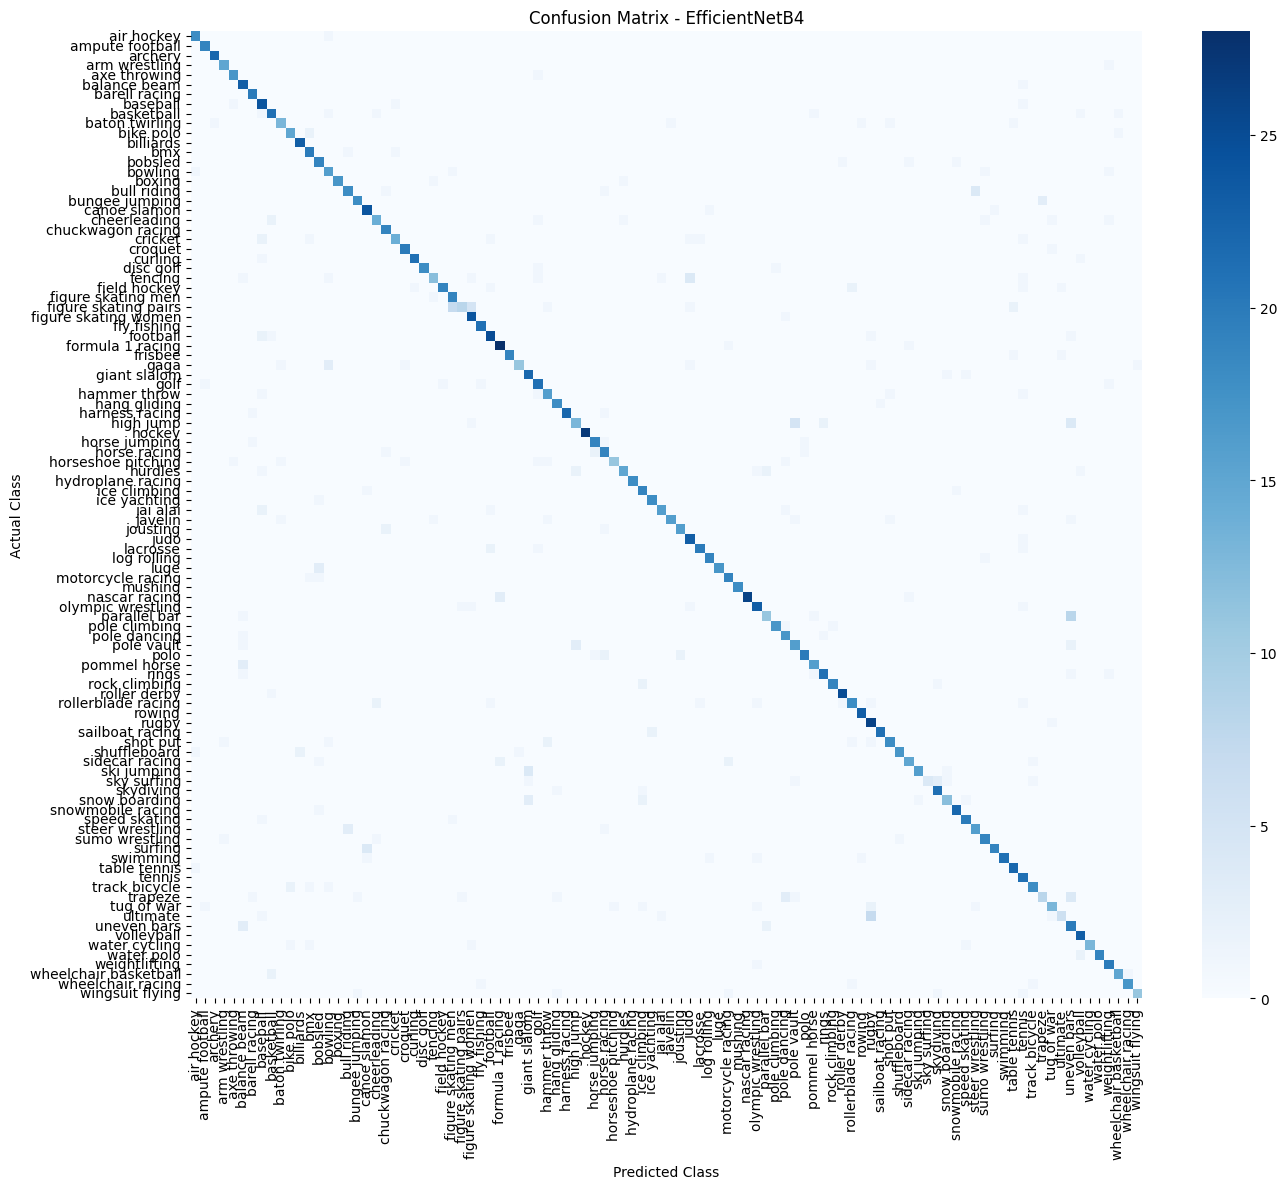

                       precision    recall  f1-score   support

           air hockey       0.86      0.95      0.90        19
      ampute football       0.90      1.00      0.95        19
              archery       0.96      1.00      0.98        22
        arm wrestling       0.88      0.94      0.91        16
         axe throwing       0.89      0.94      0.92        18
         balance beam       0.68      0.96      0.79        24
        barell racing       0.87      1.00      0.93        20
             baseball       0.67      0.89      0.76        27
           basketball       0.78      0.78      0.78        27
       baton twirling       0.81      0.72      0.76        18
            bike polo       0.83      0.83      0.83        18
            billiards       0.92      1.00      0.96        23
                  bmx       0.77      0.91      0.83        22
              bobsled       0.73      0.86      0.79        22
              bowling       0.67      0.80      0.73  

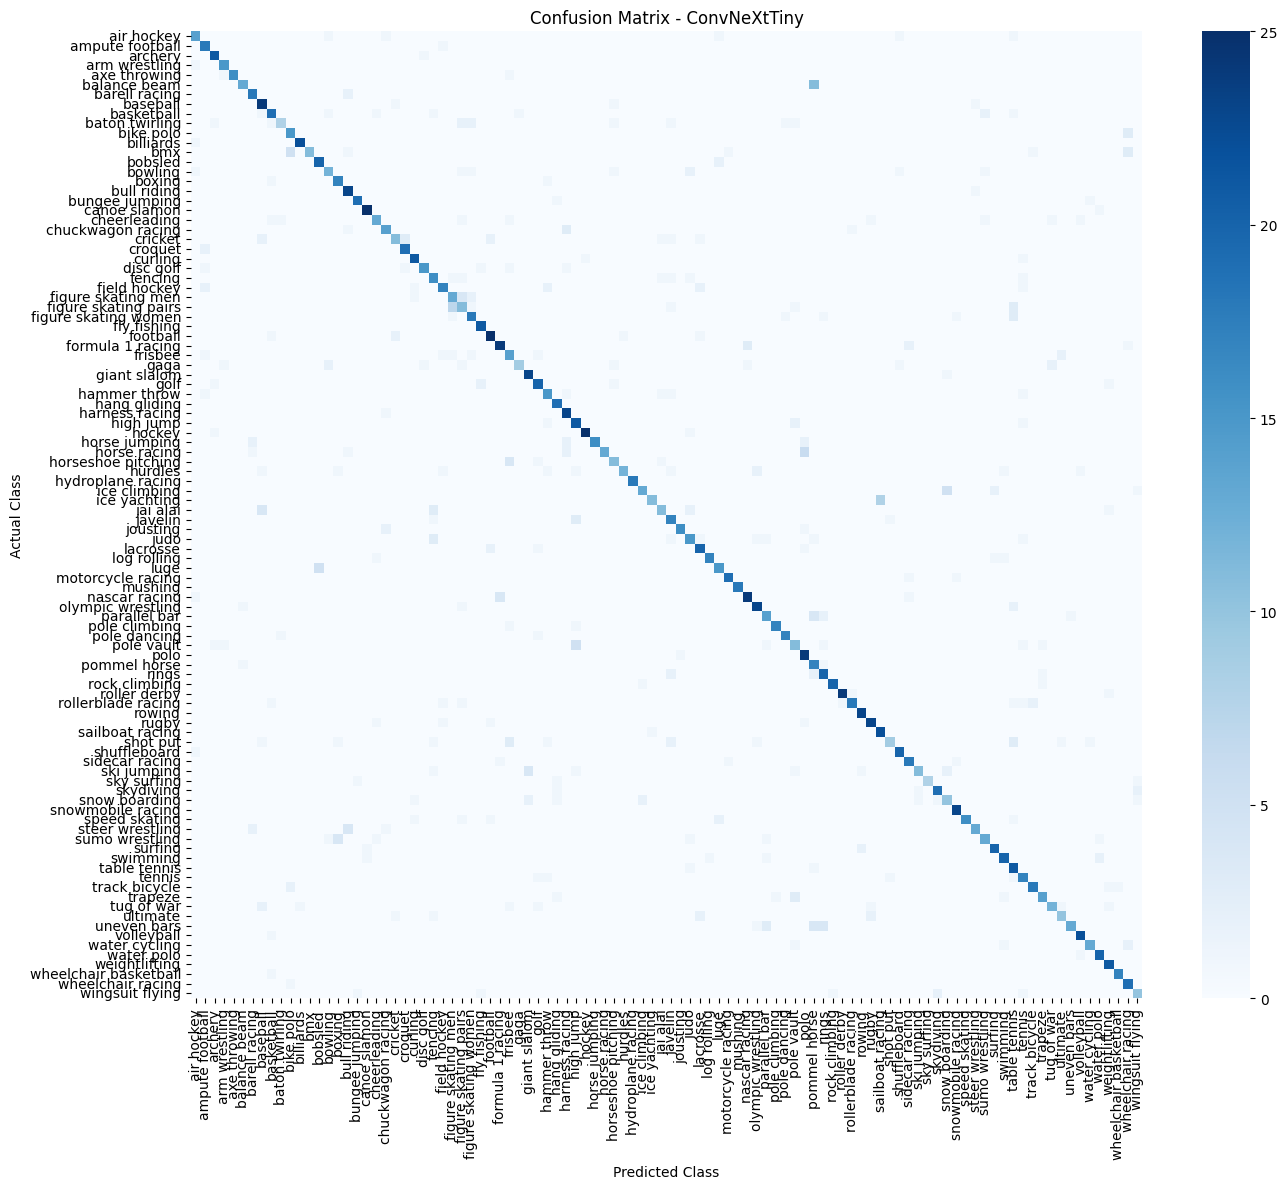

                       precision    recall  f1-score   support

           air hockey       0.74      0.74      0.74        19
      ampute football       0.72      0.95      0.82        19
              archery       0.84      0.95      0.89        22
        arm wrestling       0.83      0.94      0.88        16
         axe throwing       1.00      0.89      0.94        18
         balance beam       0.87      0.54      0.67        24
        barell racing       0.78      0.90      0.84        20
             baseball       0.69      0.89      0.77        27
           basketball       0.73      0.70      0.72        27
       baton twirling       0.80      0.44      0.57        18
            bike polo       0.65      0.83      0.73        18
            billiards       0.96      0.96      0.96        23
                  bmx       1.00      0.50      0.67        22
              bobsled       0.80      0.91      0.85        22
              bowling       0.71      0.60      0.65  

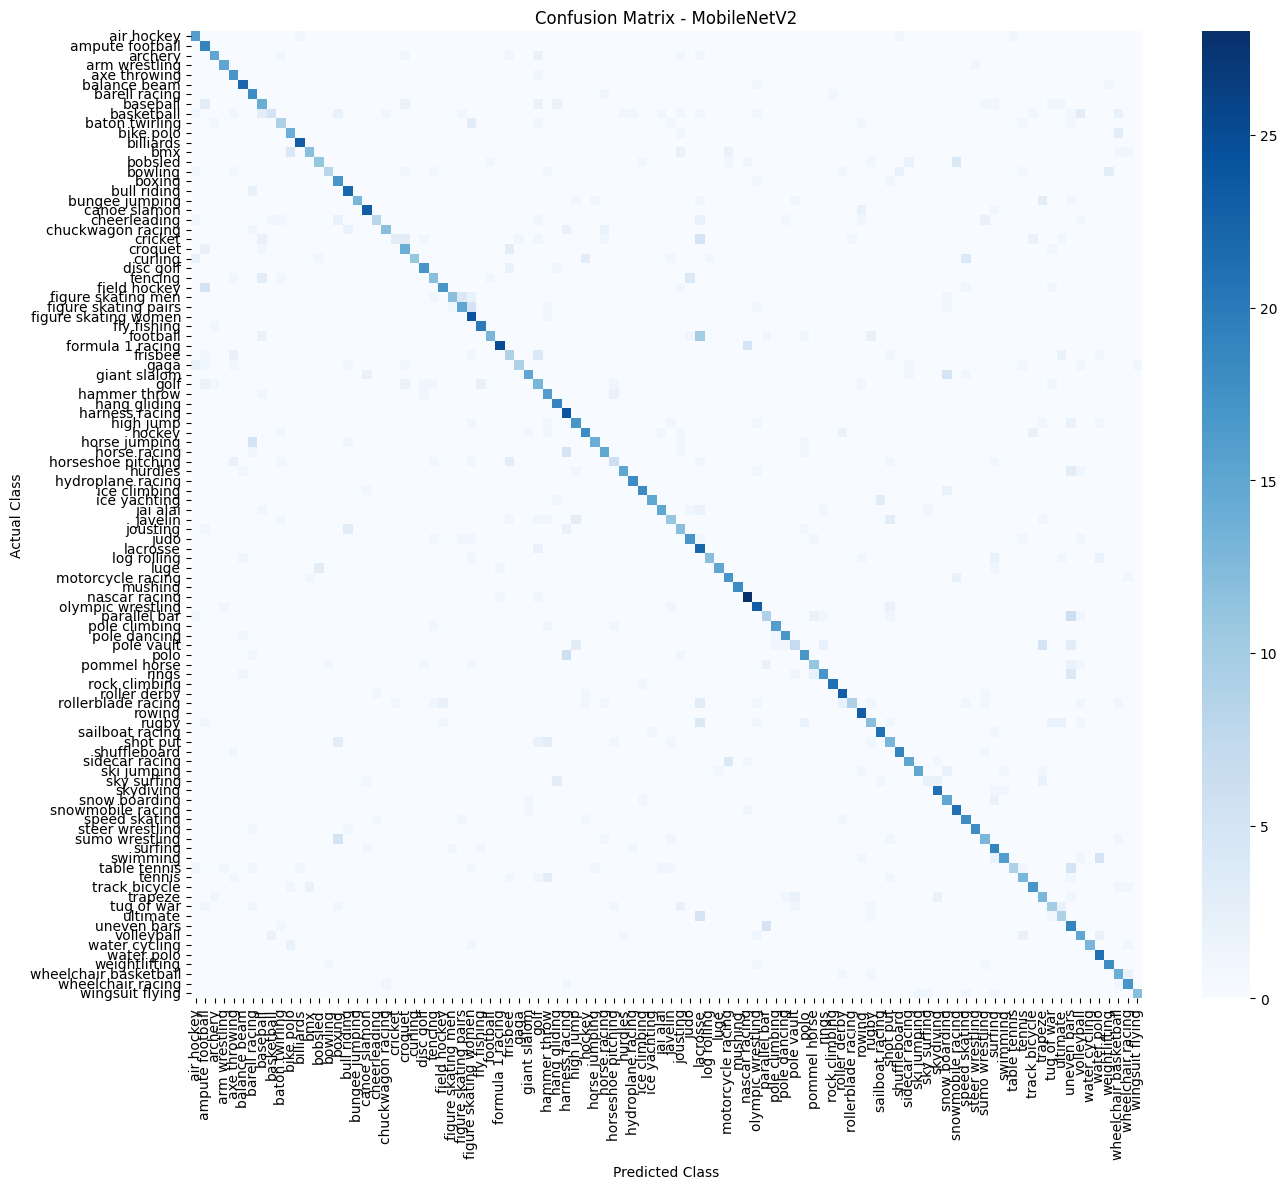

                       precision    recall  f1-score   support

           air hockey       0.64      0.84      0.73        19
      ampute football       0.53      1.00      0.69        19
              archery       0.79      0.68      0.73        22
        arm wrestling       0.88      0.94      0.91        16
         axe throwing       0.63      0.94      0.76        18
         balance beam       0.85      0.92      0.88        24
        barell racing       0.58      0.90      0.71        20
             baseball       0.52      0.52      0.52        27
           basketball       0.62      0.19      0.29        27
       baton twirling       0.56      0.50      0.53        18
            bike polo       0.67      0.78      0.72        18
            billiards       0.92      1.00      0.96        23
                  bmx       0.80      0.55      0.65        22
              bobsled       0.73      0.50      0.59        22
              bowling       0.80      0.40      0.53  

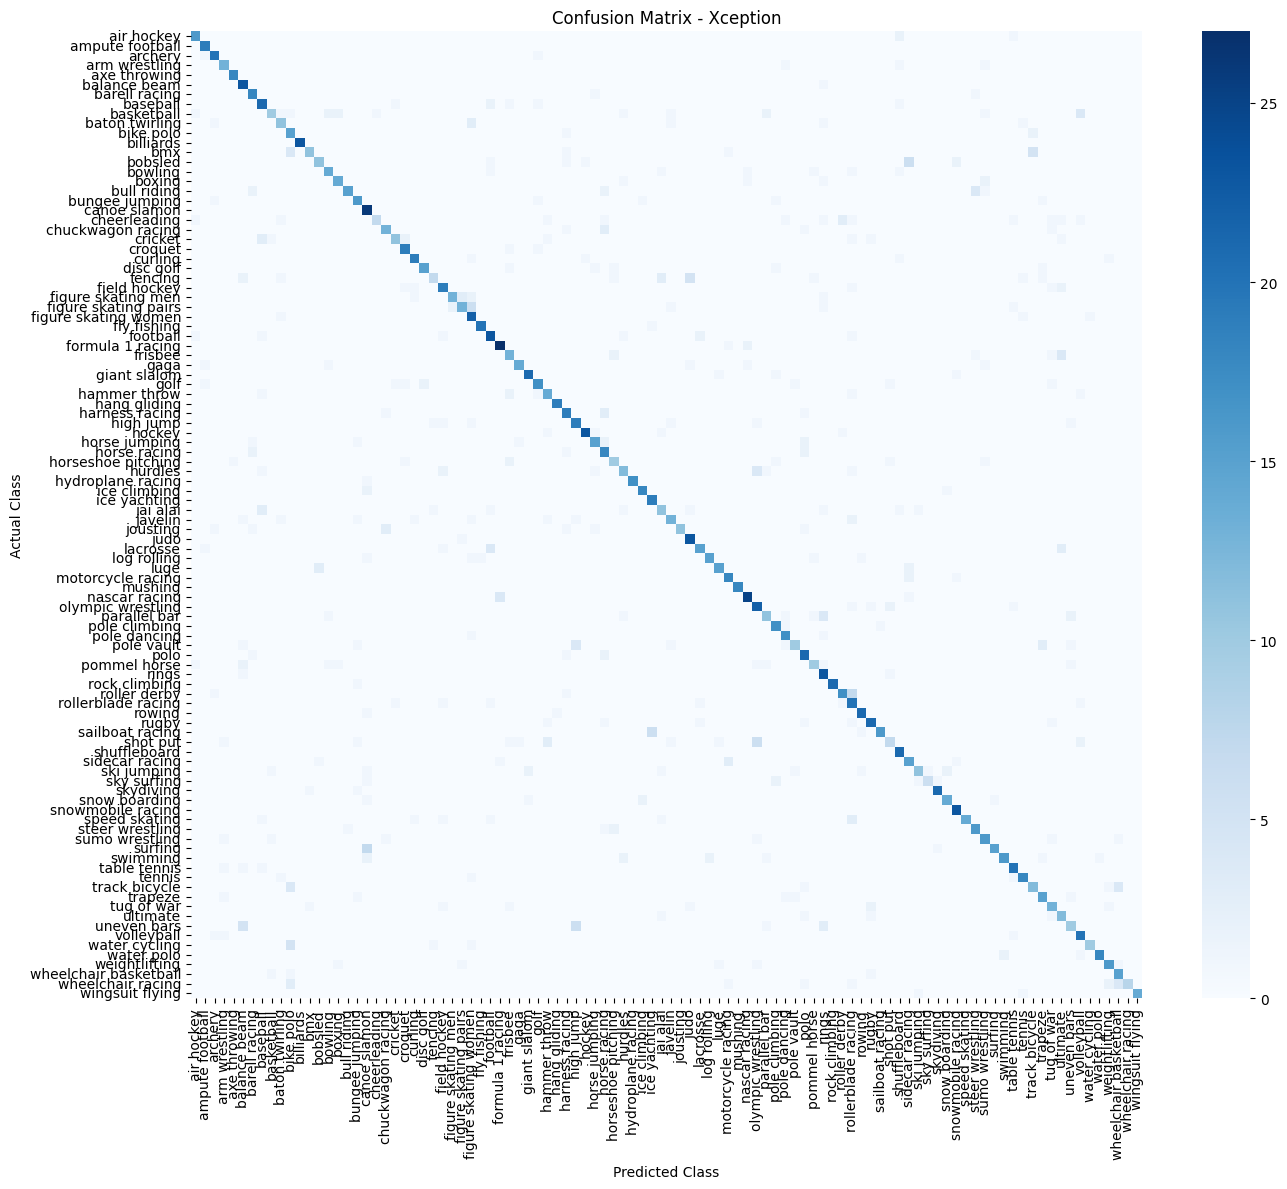

                       precision    recall  f1-score   support

           air hockey       0.80      0.84      0.82        19
      ampute football       0.83      1.00      0.90        19
              archery       0.80      0.91      0.85        22
        arm wrestling       0.72      0.81      0.76        16
         axe throwing       0.95      1.00      0.97        18
         balance beam       0.64      0.96      0.77        24
        barell racing       0.72      0.90      0.80        20
             baseball       0.66      0.78      0.71        27
           basketball       0.71      0.37      0.49        27
       baton twirling       0.65      0.61      0.63        18
            bike polo       0.45      0.83      0.59        18
            billiards       1.00      1.00      1.00        23
                  bmx       0.85      0.50      0.63        22
              bobsled       0.73      0.50      0.59        22
              bowling       0.74      0.70      0.72  

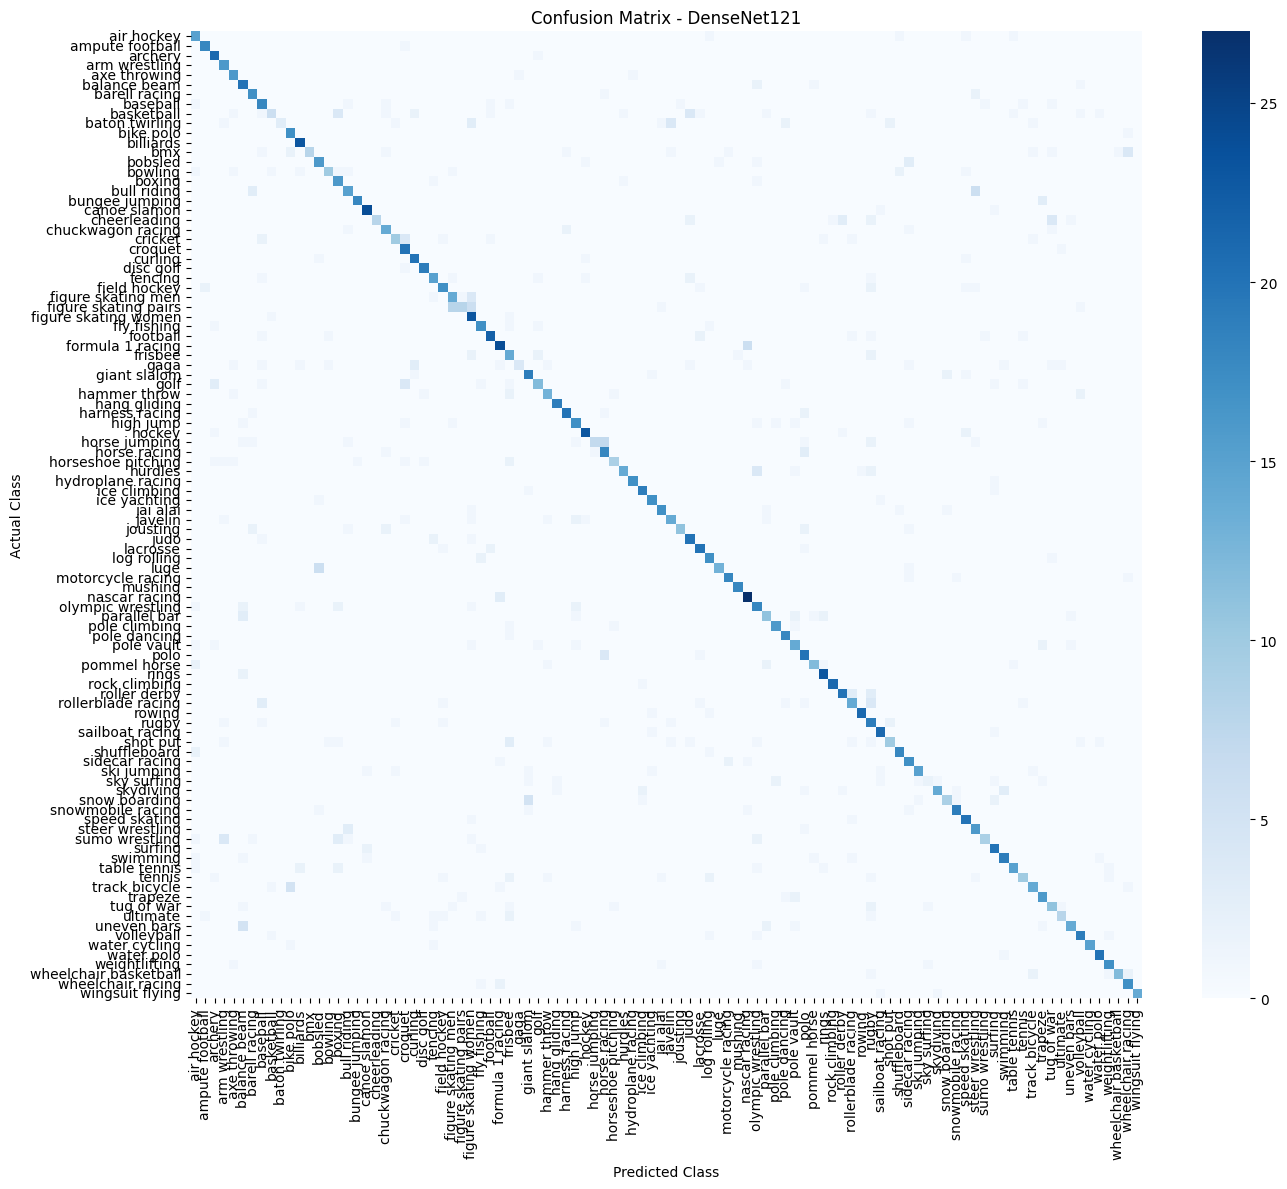

                       precision    recall  f1-score   support

           air hockey       0.58      0.79      0.67        19
      ampute football       0.86      0.95      0.90        19
              archery       0.72      0.95      0.82        22
        arm wrestling       0.64      1.00      0.78        16
         axe throwing       0.73      0.89      0.80        18
         balance beam       0.56      0.83      0.67        24
        barell racing       0.68      0.85      0.76        20
             baseball       0.58      0.67      0.62        27
           basketball       0.60      0.22      0.32        27
       baton twirling       1.00      0.17      0.29        18
            bike polo       0.68      0.94      0.79        18
            billiards       0.82      1.00      0.90        23
                  bmx       1.00      0.36      0.53        22
              bobsled       0.64      0.73      0.68        22
              bowling       0.77      0.50      0.61  

In [10]:
# ============================================================
# MODULE 5: TRAINING AND EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


def compile_model(model):

    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=0.0003
        ),

        loss=keras.losses.CategoricalCrossentropy(
            label_smoothing=0.1
        ),

        metrics=[
            "accuracy"
        ]
    )

    return model


def evaluate_model(model, dataset):

    y_true = []
    y_probability = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_probability.extend(
            predictions
        )

        y_true.extend(
            labels.numpy()
        )

    y_true = np.array(y_true)

    y_probability = np.array(
        y_probability
    )

    true_classes = np.argmax(
        y_true,
        axis=1
    )

    predicted_classes = np.argmax(
        y_probability,
        axis=1
    )

    accuracy = accuracy_score(
        true_classes,
        predicted_classes
    )

    precision = precision_score(
        true_classes,
        predicted_classes,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        true_classes,
        predicted_classes,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        true_classes,
        predicted_classes,
        average="weighted",
        zero_division=0
    )

    try:

        roc_auc = roc_auc_score(
            y_true,
            y_probability,
            multi_class="ovr",
            average="weighted"
        )

    except Exception:

        roc_auc = np.nan

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "probabilities": y_probability
    }


# ------------------------------------------------------------
# TRAIN ALL MODELS
# ------------------------------------------------------------

histories = {}

evaluation_results = {}

for model_name in MODEL_NAMES:

    print("\n" + "=" * 60)

    print(
        "Training model:",
        model_name
    )

    print("=" * 60)

    model = models[model_name]

    compile_model(model)

    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=1,
            min_lr=1e-7
        )

    ]

    start_time = time.time()

    history = model.fit(

        train_dataset,

        validation_data=validation_dataset,

        epochs=EPOCHS,

        callbacks=callbacks
    )

    training_time = (
        time.time() - start_time
    )

    histories[model_name] = history

    evaluation = evaluate_model(
        model,
        test_dataset
    )

    evaluation["parameters"] = (
        model.count_params()
    )

    evaluation["training_time_seconds"] = (
        training_time
    )

    evaluation_results[model_name] = evaluation

    print("\nEvaluation results:")

    print(
        "Accuracy:",
        evaluation["accuracy"]
    )

    print(
        "Precision:",
        evaluation["precision"]
    )

    print(
        "Recall:",
        evaluation["recall"]
    )

    print(
        "F1 Score:",
        evaluation["f1_score"]
    )

    print(
        "ROC-AUC:",
        evaluation["roc_auc"]
    )

    # Save model
    model.save(
        OUTPUT_DIR / f"{model_name}.keras"
    )

# ------------------------------------------------------------
# COMPARISON TABLE
# ------------------------------------------------------------

comparison_rows = []

for model_name, result in evaluation_results.items():

    comparison_rows.append({

        "Model": model_name,

        "Accuracy": result["accuracy"],

        "Precision": result["precision"],

        "Recall": result["recall"],

        "F1 Score": result["f1_score"],

        "ROC-AUC": result["roc_auc"],

        "Parameters": result["parameters"],

        "Training Time (seconds)": result[
            "training_time_seconds"
        ]

    })

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

display(comparison_df)

comparison_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

for model_name, result in evaluation_results.items():

    cm = confusion_matrix(
        result["true_classes"],
        result["predicted_classes"]
    )

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Class")

    plt.ylabel("Actual Class")

    plt.xticks(rotation=90)

    plt.yticks(rotation=0)

    plt.tight_layout()

    plt.show()

    print(
        classification_report(
            result["true_classes"],
            result["predicted_classes"],
            target_names=class_names,
            zero_division=0
        )
    )

print("MODULE 5 COMPLETED")

In [11]:
# ============================================================
# MODULE 6: OPTIMIZATION AND BEST MODEL SELECTION
# ============================================================

# Optimization techniques used:
#
# 1. Data augmentation
# 2. Label smoothing
# 3. ReduceLROnPlateau
# 4. Early stopping
# 5. Transfer learning
# 6. Fine-tuning selected model


# ------------------------------------------------------------
# SELECT INITIAL BEST MODEL
# ------------------------------------------------------------

best_model_name = comparison_df.iloc[0]["Model"]

print(
    "Initial best model based on F1 Score:",
    best_model_name
)

best_model = models[best_model_name]


# ------------------------------------------------------------
# FINE-TUNING
# ------------------------------------------------------------

print("\nStarting fine-tuning...")

# Find the backbone
backbone = best_model.get_layer(
    "resnet50"
) if best_model_name in [
    "ResNet50",
    "ResNet50_CBAM"
] else None

# Identify nested backbone by checking model layers
if backbone is None:

    for layer in best_model.layers:

        if isinstance(layer, keras.Model):

            backbone = layer

            break

if backbone is not None:

    backbone.trainable = True

    # Freeze most layers and unfreeze final layers
    fine_tune_from = max(
        0,
        len(backbone.layers) - 30
    )

    for layer_index, layer in enumerate(
        backbone.layers
    ):

        if layer_index < fine_tune_from:

            layer.trainable = False

        else:

            layer.trainable = True

# Compile with smaller learning rate
best_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy"
    ]
)

fine_tune_callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-8
    )

]

fine_tune_history = best_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=fine_tune_callbacks
)


# ------------------------------------------------------------
# EVALUATE FINE-TUNED MODEL
# ------------------------------------------------------------

fine_tuned_result = evaluate_model(
    best_model,
    test_dataset
)

print("\nFine-tuned model results:")

print(
    "Accuracy:",
    fine_tuned_result["accuracy"]
)

print(
    "Precision:",
    fine_tuned_result["precision"]
)

print(
    "Recall:",
    fine_tuned_result["recall"]
)

print(
    "F1 Score:",
    fine_tuned_result["f1_score"]
)

print(
    "ROC-AUC:",
    fine_tuned_result["roc_auc"]
)


# ------------------------------------------------------------
# INFERENCE SPEED
# ------------------------------------------------------------

def measure_inference_speed(
    model,
    dataset,
    number_of_batches=10
):

    total_images = 0

    start_time = time.time()

    for batch_index, (images, labels) in enumerate(dataset):

        if batch_index >= number_of_batches:

            break

        model.predict(
            images,
            verbose=0
        )

        total_images += images.shape[0]

    elapsed_time = (
        time.time() - start_time
    )

    if total_images == 0:

        return np.nan

    milliseconds_per_image = (
        elapsed_time / total_images
    ) * 1000

    return milliseconds_per_image


inference_results = []

for model_name, model in models.items():

    latency = measure_inference_speed(
        model,
        test_dataset
    )

    inference_results.append({

        "Model": model_name,

        "Inference Time (ms/image)": latency,

        "Parameters": model.count_params(),

        "F1 Score": evaluation_results[
            model_name
        ]["f1_score"]

    })

inference_df = pd.DataFrame(
    inference_results
)

display(inference_df)


# ------------------------------------------------------------
# SAVE FINE-TUNED MODEL
# ------------------------------------------------------------

best_model.save(
    OUTPUT_DIR / "best_fine_tuned_model.keras"
)

print(
    "Fine-tuned model saved."
)

print("MODULE 6 COMPLETED")

Initial best model based on F1 Score: EfficientNetB4

Starting fine-tuning...
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 220s 133ms/step - accuracy: 0.4868 - loss: 2.5887 - val_accuracy: 0.7484 - val_loss: 1.6864 - learning_rate: 1.0000e-05

Fine-tuned model results:
Accuracy: 0.7442502299908004
Precision: 0.7572334698839038
Recall: 0.7442502299908004
F1 Score: 0.7355888505939386
ROC-AUC: 0.992267795949507


,Model,Inference Time (ms/image),Parameters,F1 Score
0,ResNet50,17.603531,23800804,0.788160
1,ResNet50_CBAM,21.855780,24851783,0.561681
2,EfficientNetB4,14.378536,17860291,0.834470
3,ConvNeXtTiny,15.426207,27900100,0.780068
4,MobileNetV2,11.534700,2391204,0.698773
5,Xception,15.208143,21074572,0.738507
6,DenseNet121,14.303067,7144100,0.718659


Fine-tuned model saved.
MODULE 6 COMPLETED


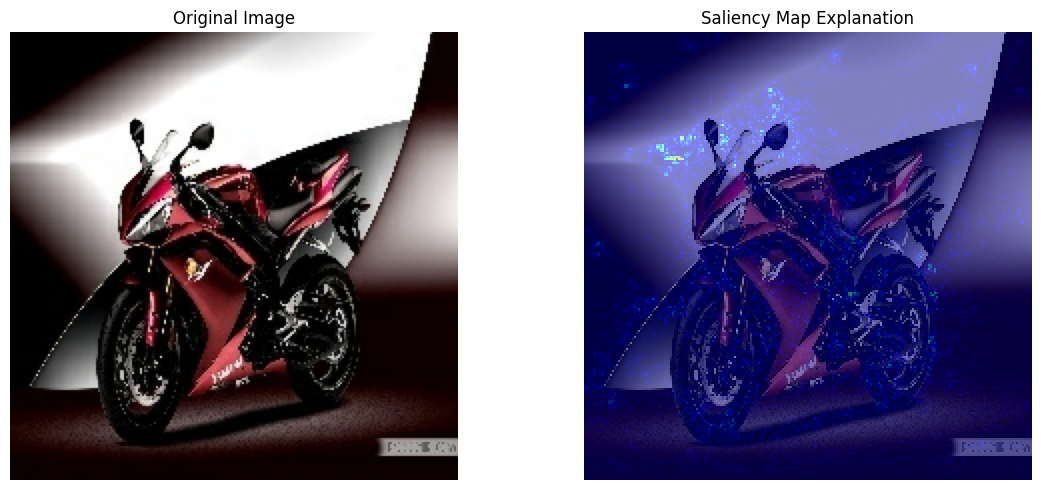

Predicted class: motorcycle racing
Confidence: 92.67%


In [13]:
# ============================================================
# FIXED MODULE 7: SALIENCY MAP + OCCLUSION SENSITIVITY
# ============================================================


# ------------------------------------------------------------
# LOAD ONE TEST IMAGE
# ------------------------------------------------------------

def load_single_image(image_path):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image


# ------------------------------------------------------------
# SALIENCY MAP
# ------------------------------------------------------------

def make_saliency_heatmap(
    model,
    image,
    target_class=None
):

    image_batch = tf.expand_dims(
        image,
        axis=0
    )

    with tf.GradientTape() as tape:

        tape.watch(image_batch)

        predictions = model(
            image_batch,
            training=False
        )

        if target_class is None:

            target_class = tf.argmax(
                predictions[0]
            )

        class_score = predictions[
            :, target_class
        ]

    gradients = tape.gradient(
        class_score,
        image_batch
    )

    # Absolute gradients
    saliency = tf.abs(
        gradients
    )

    # Maximum across RGB channels
    saliency = tf.reduce_max(
        saliency,
        axis=-1
    )

    saliency = saliency[0]

    # Normalize between 0 and 1
    saliency = (
        saliency - tf.reduce_min(saliency)
    ) / (
        tf.reduce_max(saliency)
        - tf.reduce_min(saliency)
        + 1e-8
    )

    return saliency.numpy(), int(target_class)


# ------------------------------------------------------------
# DISPLAY SALIENCY MAP
# ------------------------------------------------------------

def display_saliency_map(
    model,
    image_path
):

    image = load_single_image(
        image_path
    )

    predictions = model.predict(
        tf.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_class = np.argmax(
        predictions[0]
    )

    heatmap, target_class = make_saliency_heatmap(
        model,
        image,
        predicted_class
    )

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    plt.figure(figsize=(12, 5))

    # Original image
    plt.subplot(1, 2, 1)

    plt.imshow(
        tf.cast(image, tf.uint8)
    )

    plt.title(
        "Original Image"
    )

    plt.axis("off")

    # Saliency map
    plt.subplot(1, 2, 2)

    plt.imshow(
        tf.cast(image, tf.uint8)
    )

    plt.imshow(
        heatmap,
        cmap="jet",
        alpha=0.5
    )

    plt.title(
        "Saliency Map Explanation"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

    print(
        "Predicted class:",
        class_names[predicted_class]
    )

    print(
        "Confidence:",
        f"{predictions[0][predicted_class] * 100:.2f}%"
    )


# ------------------------------------------------------------
# RUN SALIENCY MAP
# ------------------------------------------------------------

example_image_path = test_df.iloc[0]["path"]

display_saliency_map(
    best_model,
    example_image_path
)

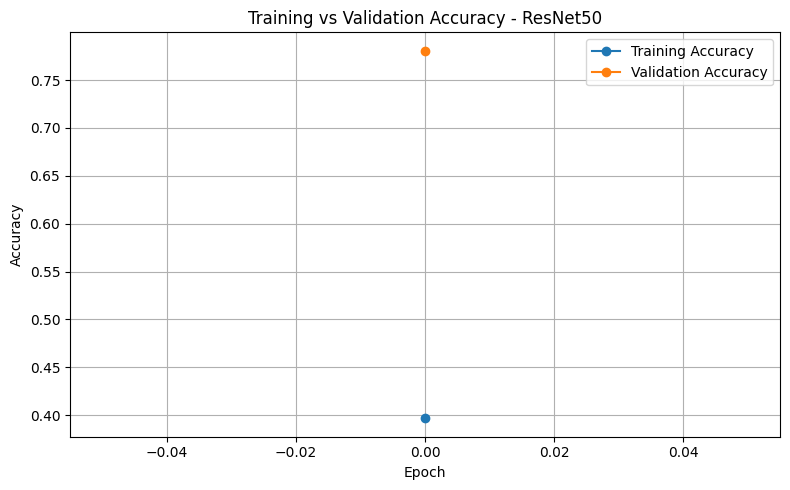

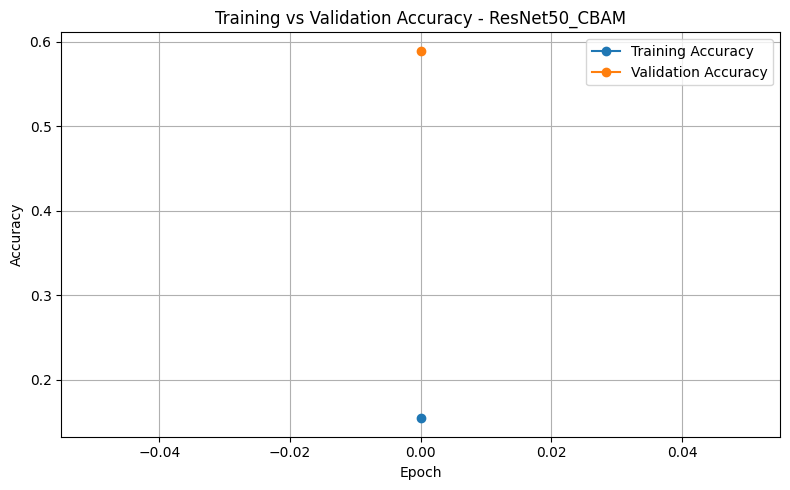

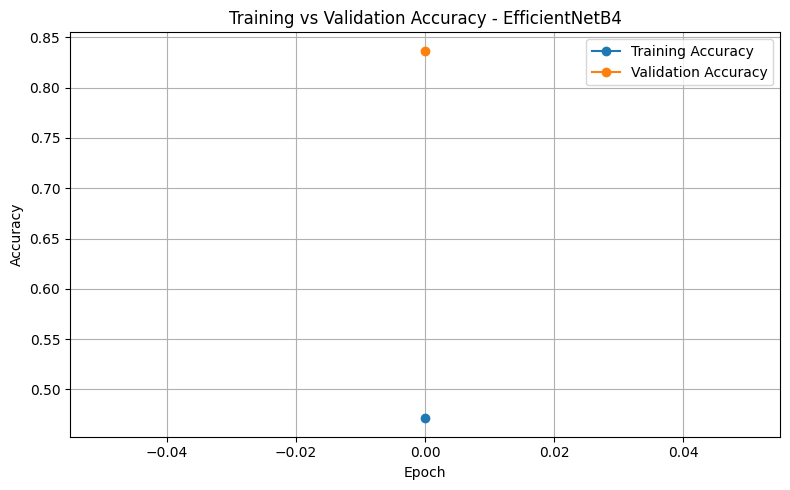

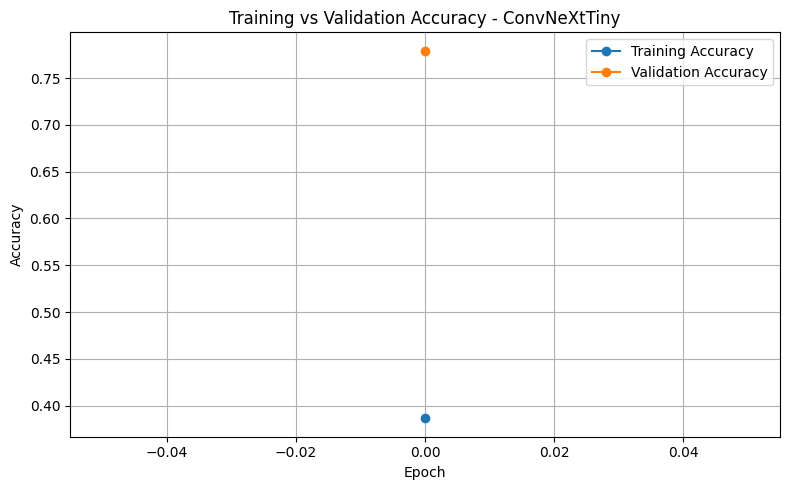

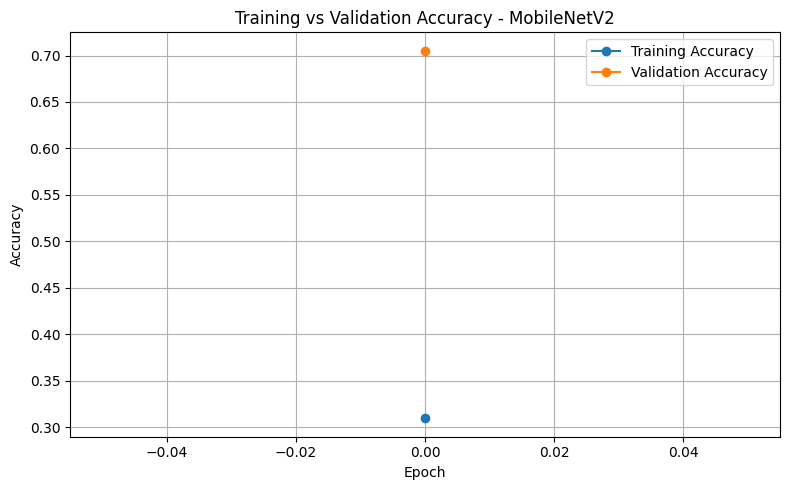

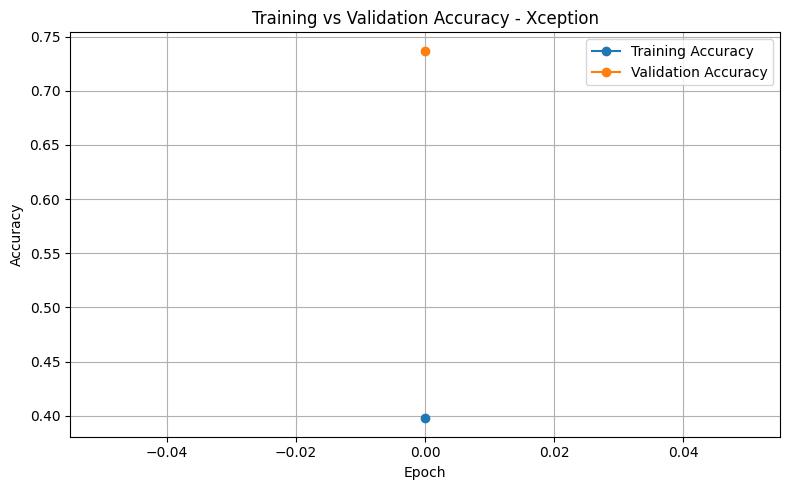

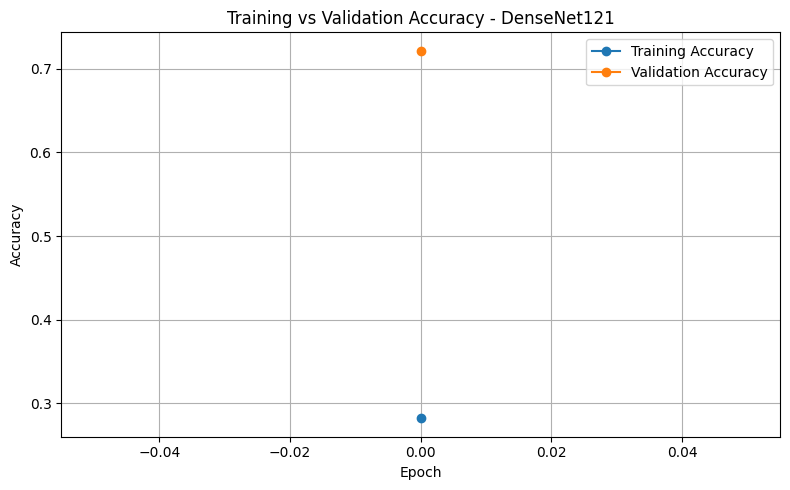

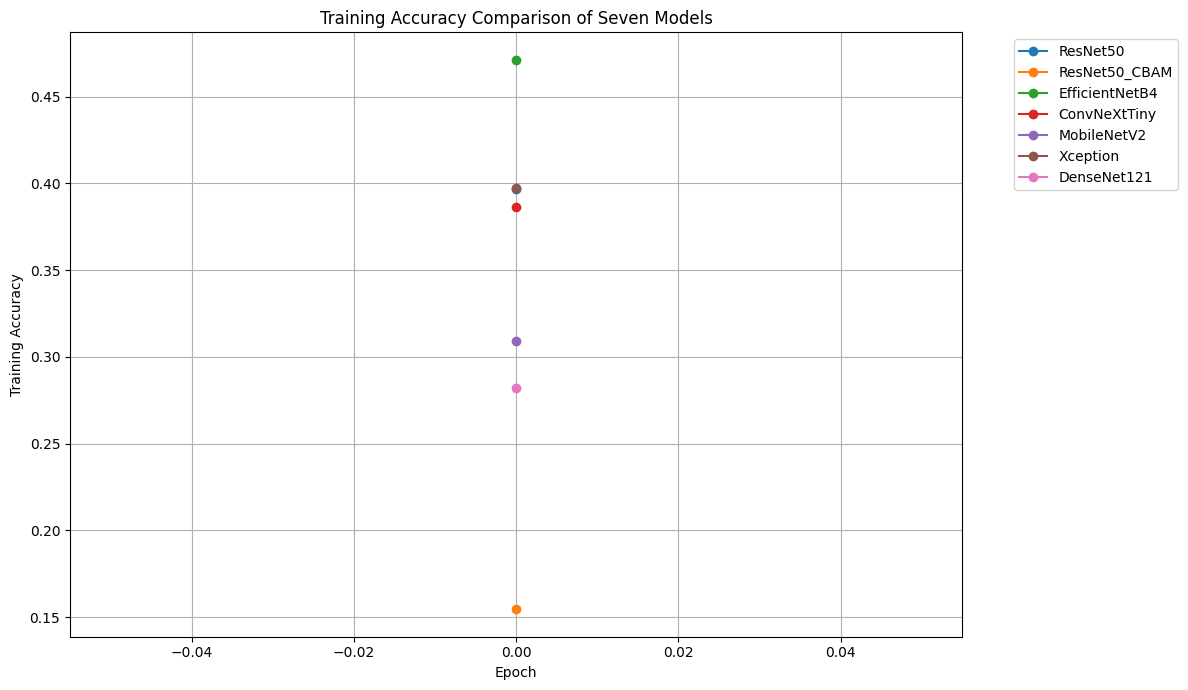

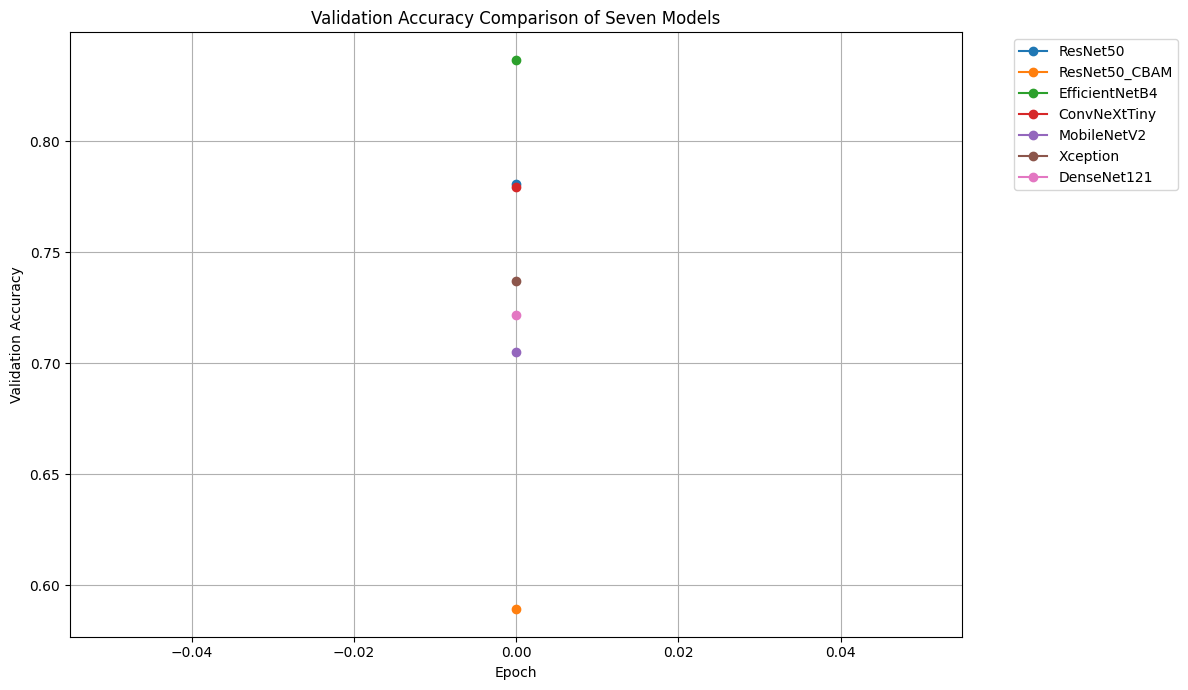

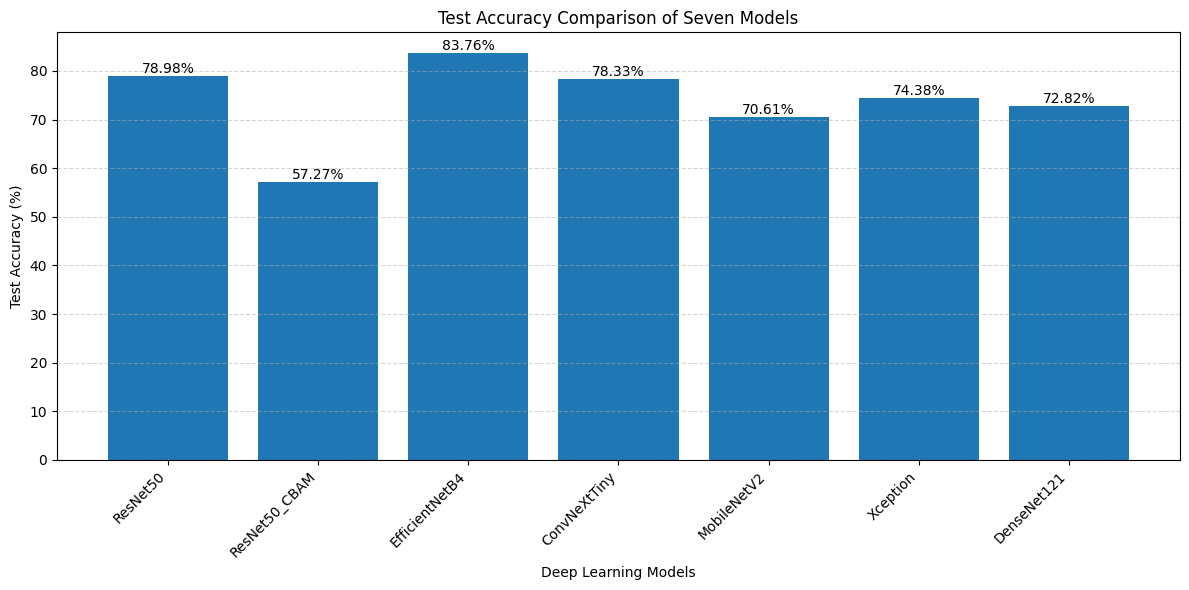

,Model,Test Accuracy (%)
2,EfficientNetB4,83.762649
0,ResNet50,78.978841
3,ConvNeXtTiny,78.334867
5,Xception,74.379025
6,DenseNet121,72.815087
4,MobileNetV2,70.607176
1,ResNet50_CBAM,57.267709


All accuracy graphs saved in: /content/sports_outputs


In [14]:
# ============================================================
# ACCURACY GRAPHS FOR ALL 7 MODELS
# ============================================================

# ------------------------------------------------------------
# 1. INDIVIDUAL TRAINING AND VALIDATION ACCURACY GRAPHS
# ------------------------------------------------------------

for model_name, history in histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.title(
        f"Training vs Validation Accuracy - {model_name}"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"{model_name}_accuracy.png",
        dpi=300
    )

    plt.show()


# ------------------------------------------------------------
# 2. COMBINED TRAINING ACCURACY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for model_name, history in histories.items():

    plt.plot(
        history.history["accuracy"],
        marker="o",
        label=model_name
    )

plt.title(
    "Training Accuracy Comparison of Seven Models"
)

plt.xlabel("Epoch")

plt.ylabel("Training Accuracy")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "combined_training_accuracy.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 3. COMBINED VALIDATION ACCURACY GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

for model_name, history in histories.items():

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=model_name
    )

plt.title(
    "Validation Accuracy Comparison of Seven Models"
)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "combined_validation_accuracy.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 4. FINAL TEST ACCURACY BAR GRAPH
# ------------------------------------------------------------

model_names_graph = list(
    evaluation_results.keys()
)

test_accuracies = [

    evaluation_results[name]["accuracy"] * 100

    for name in model_names_graph

]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    model_names_graph,
    test_accuracies
)

plt.title(
    "Test Accuracy Comparison of Seven Models"
)

plt.xlabel("Deep Learning Models")

plt.ylabel("Test Accuracy (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

# Display accuracy values above bars
for bar, accuracy in zip(
    bars,
    test_accuracies
):

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        bar.get_height(),

        f"{accuracy:.2f}%",

        ha="center",

        va="bottom"

    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "test_accuracy_comparison.png",
    dpi=300
)

plt.show()


# ------------------------------------------------------------
# 5. SAVE ACCURACY RESULTS
# ------------------------------------------------------------

accuracy_table = pd.DataFrame({

    "Model": model_names_graph,

    "Test Accuracy (%)": test_accuracies

})

accuracy_table = accuracy_table.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

display(accuracy_table)

accuracy_table.to_csv(
    OUTPUT_DIR / "accuracy_comparison.csv",
    index=False
)

print(
    "All accuracy graphs saved in:",
    OUTPUT_DIR
)